# Auto-Encoder & Variational Auto-Encoder — Minecraft Item Textures
**Merlijn Waaijer**

This notebook implements an AE and VAE on the Minecraft item texture dataset (16x16 PNG files).
The notebook is divided into the following sections:
1. Imports & configuration
2. Load dataset
3. Auto-Encoder (AE)
4. Variational Auto-Encoder (VAE)
5. Reconstruction quality comparison
6. Latent space arithmetic

## 1. Imports & configuration

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.manifold import TSNE

# Use GPU if available, otherwise CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

IMG_SIZE    = 16          # Minecraft textures are 16x16 pixels
CHANNELS    = 4           # RGBA (PNG with transparency)
LATENT_DIM  = 32          # Size of latent vector z
BATCH_SIZE  = 64
EPOCHS_AE   = 50
EPOCHS_VAE  = 50
LR          = 1e-3        # Learning rate
BETA        = 0.03        # Lower KL weight to reduce blur in VAE reconstructions
DATA_DIR    = 'minecraft-items'

Device: cuda


## 2. Load dataset

Number of textures loaded: 719


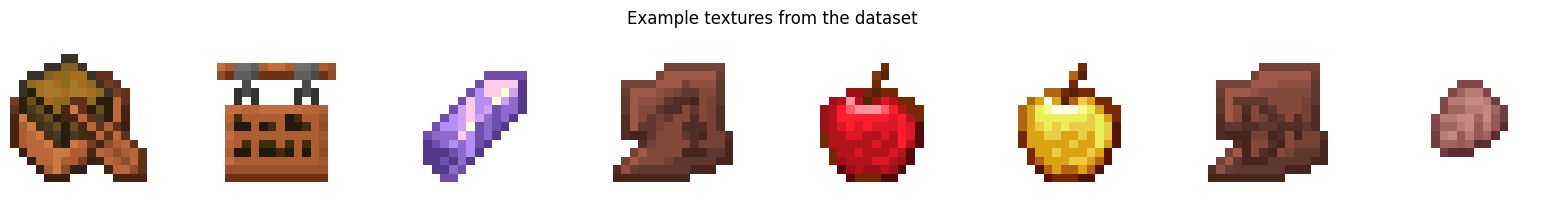

In [ ]:
class MinecraftDataset(Dataset):
    """
    Loads all PNG files from DATA_DIR.
    Each image is converted to a tensor of shape (4, 16, 16)
    with pixel values normalized to [0, 1].
    """
    def __init__(self, root_dir, transform=None):
        self.paths = [
            os.path.join(root_dir, f)
            for f in os.listdir(root_dir)
            if f.endswith('.png')
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        # Load as RGBA so transparency is preserved
        img = Image.open(self.paths[idx]).convert('RGBA')
        if self.transform:
            img = self.transform(img)
        return img, self.paths[idx]


# Transform: PIL Image -> Tensor with values in [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
])

dataset    = MinecraftDataset(DATA_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f'Number of textures loaded: {len(dataset)}')

# Show a few example images
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img_tensor, _ = dataset[i]
    # Convert RGBA tensor to numpy for display (H, W, C)
    img_np = img_tensor.permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.axis('off')
plt.suptitle('Example textures from the dataset')
plt.tight_layout()
plt.show()

## 3. Auto-Encoder (AE)

In [ ]:
class AEEncoder(nn.Module):
    """
    AE encoder.
    Compresses input (4 x 16 x 16) into a latent vector z of size LATENT_DIM.
    Uses fully connected layers with ReLU activation.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                                        # (4,16,16) -> (1024,)
            nn.Linear(CHANNELS * IMG_SIZE * IMG_SIZE, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, LATENT_DIM),
        )

    def forward(self, x):
        return self.net(x)


class AEDecoder(nn.Module):
    """
    AE decoder.
    Reconstructs latent vector z back into an image (4 x 16 x 16).
    Uses sigmoid as final activation so output stays in [0, 1].
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, CHANNELS * IMG_SIZE * IMG_SIZE),
            nn.Sigmoid(),                                        # Output in [0, 1]
        )

    def forward(self, z):
        # Reshape flat output back to (batch, C, H, W)
        return self.net(z).view(-1, CHANNELS, IMG_SIZE, IMG_SIZE)


class AutoEncoder(nn.Module):
    """Combines encoder and decoder into a complete AE."""
    def __init__(self):
        super().__init__()
        self.encoder = AEEncoder()
        self.decoder = AEDecoder()

    def forward(self, x):
        z    = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

AE Epoch [10/50] - Loss: 0.053070
AE Epoch [20/50] - Loss: 0.035573
AE Epoch [30/50] - Loss: 0.025982
AE Epoch [40/50] - Loss: 0.020852
AE Epoch [50/50] - Loss: 0.017202


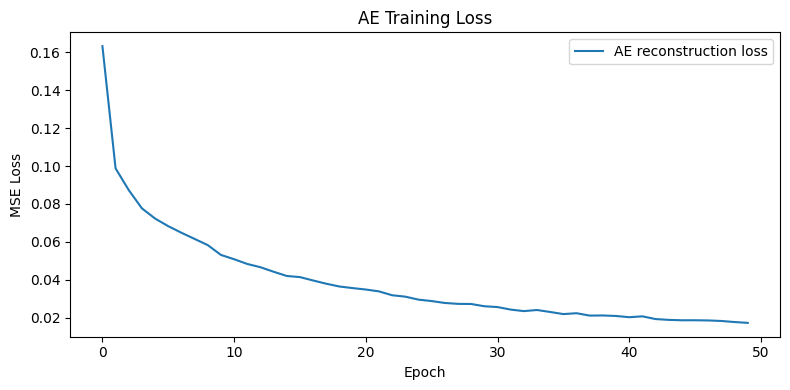

In [22]:
def train_ae(model, dataloader, epochs, lr):
    """
    Trains the AE with Mean Squared Error (MSE) as reconstruction loss.
    Returns a list of loss values per epoch for evaluation.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()   # MSE measures mean squared difference between input and reconstruction
    loss_history = []

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for imgs, _ in dataloader:
            imgs = imgs.to(DEVICE)
            optimizer.zero_grad()
            x_hat, _ = model(imgs)
            loss = criterion(x_hat, imgs)   # Reconstruction loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        loss_history.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f'AE Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.6f}')

    return loss_history


# Initialize and train AE
ae_model = AutoEncoder().to(DEVICE)
ae_loss  = train_ae(ae_model, dataloader, EPOCHS_AE, LR)

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(ae_loss, label='AE reconstruction loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('AE Training Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Variational Auto-Encoder (VAE)

In [23]:
class VAEEncoder(nn.Module):
    """
    VAE encoder.
    Instead of one fixed latent vector, the encoder learns two vectors:
    mu (mean) and log_var (log-variance) of distribution q(z|x).
    """
    def __init__(self):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(CHANNELS * IMG_SIZE * IMG_SIZE, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.fc_mu      = nn.Linear(128, LATENT_DIM)   # Mean of the distribution
        self.fc_log_var = nn.Linear(128, LATENT_DIM)   # Log-variance of the distribution

    def forward(self, x):
        h       = self.shared(x)
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var


class VAEDecoder(nn.Module):
    """VAE decoder - identical to AE decoder."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, CHANNELS * IMG_SIZE * IMG_SIZE),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z).view(-1, CHANNELS, IMG_SIZE, IMG_SIZE)


class VAE(nn.Module):
    """Full VAE with reparameterization trick."""
    def __init__(self):
        super().__init__()
        self.encoder = VAEEncoder()
        self.decoder = VAEDecoder()

    def reparametrize(self, mu, log_var):
        """
        Reparameterization trick: z = mu + std * epsilon
        where epsilon ~ N(0, I).
        This allows backpropagation through the sampling step.
        """
        std     = torch.exp(0.5 * log_var)   # std = e^(0.5 * log_var)
        epsilon = torch.randn_like(std)       # epsilon ~ N(0, I)
        return mu + std * epsilon

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z           = self.reparametrize(mu, log_var)
        x_hat       = self.decoder(z)
        return x_hat, mu, log_var, z

VAE Epoch [10/50] - Loss: 3840.00 | Recon: 3766.23 | KL: 2459.01
VAE Epoch [20/50] - Loss: 2521.10 | Recon: 2407.35 | KL: 3791.55
VAE Epoch [30/50] - Loss: 1845.67 | Recon: 1718.86 | KL: 4227.09
VAE Epoch [40/50] - Loss: 1533.34 | Recon: 1404.98 | KL: 4278.71
VAE Epoch [50/50] - Loss: 1295.38 | Recon: 1164.99 | KL: 4346.34


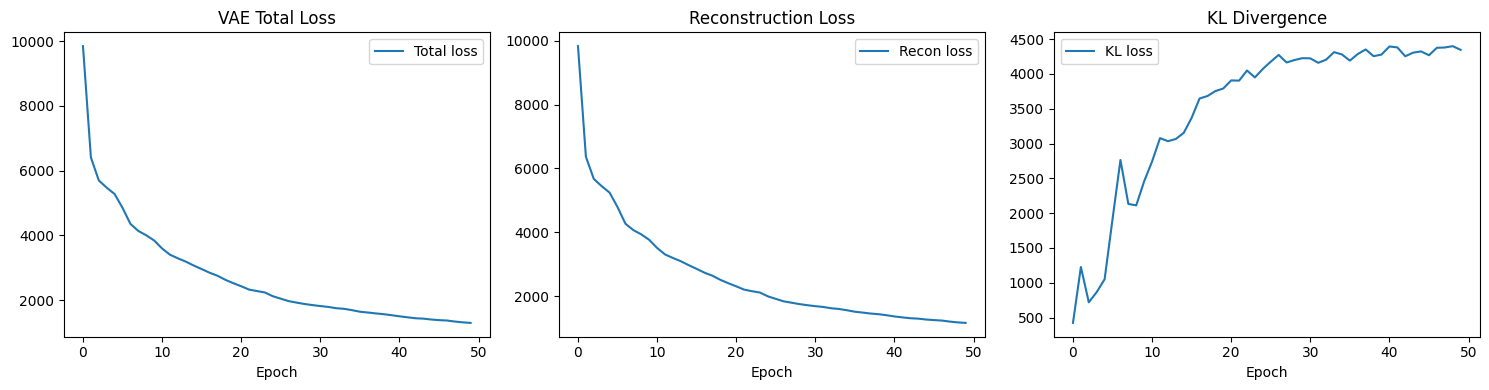

In [24]:
def vae_loss(x, x_hat, mu, log_var, beta=BETA):
    """
    ELBO loss = Reconstruction loss + beta * KL divergence

    - Reconstruction loss (MSE): how good is the reconstruction?
    - KL divergence: how far does learned distribution q(z|x)
      deviate from standard normal distribution N(0, I)?
      KL = -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    - Beta: weight of KL term (beta=1 is standard VAE)
    """
    recon_loss = nn.functional.mse_loss(x_hat, x, reduction='sum')
    kl_loss    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


def train_vae(model, dataloader, epochs, lr):
    """
    Trains the VAE with ELBO loss.
    Returns loss history for evaluation.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_history, recon_history, kl_history = [], [], []

    model.train()
    for epoch in range(epochs):
        total_loss = total_recon = total_kl = 0
        for imgs, _ in dataloader:
            imgs = imgs.to(DEVICE)
            optimizer.zero_grad()
            x_hat, mu, log_var, _ = model(imgs)
            loss, recon, kl = vae_loss(imgs, x_hat, mu, log_var)
            loss.backward()
            optimizer.step()
            total_loss  += loss.item()
            total_recon += recon.item()
            total_kl    += kl.item()

        n = len(dataloader)
        loss_history.append(total_loss  / n)
        recon_history.append(total_recon / n)
        kl_history.append(total_kl    / n)

        if (epoch + 1) % 10 == 0:
            print(f'VAE Epoch [{epoch+1}/{epochs}] - '
                  f'Loss: {total_loss/n:.2f} | '
                  f'Recon: {total_recon/n:.2f} | '
                  f'KL: {total_kl/n:.2f}')

    return loss_history, recon_history, kl_history


# Initialize and train VAE
vae_model = VAE().to(DEVICE)
vae_loss_hist, vae_recon_hist, vae_kl_hist = train_vae(vae_model, dataloader, EPOCHS_VAE, LR)

# Plot training losses
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(vae_loss_hist,  label='Total loss');  axes[0].set_title('VAE Total Loss')
axes[1].plot(vae_recon_hist, label='Recon loss');  axes[1].set_title('Reconstruction Loss')
axes[2].plot(vae_kl_hist,    label='KL loss');     axes[2].set_title('KL Divergence')
for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout()
plt.show()

## 5. Reconstruction quality comparison

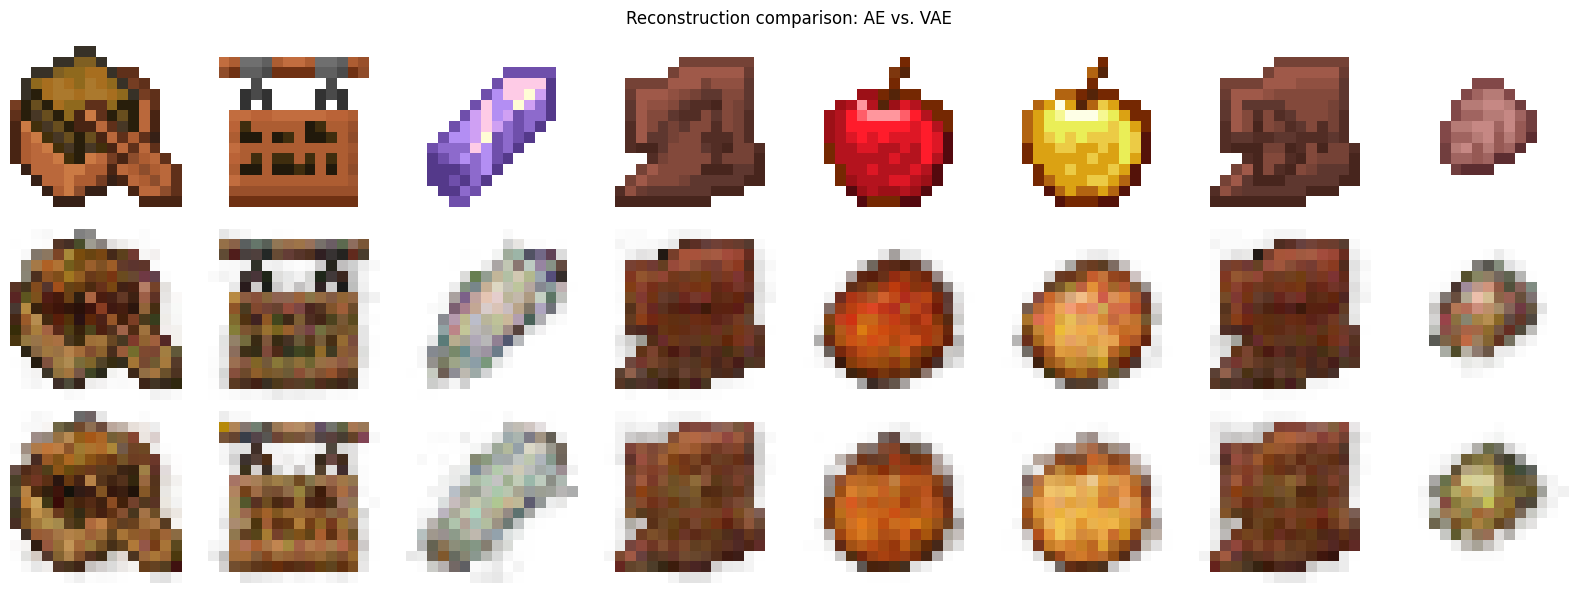

AE  average MSE: 0.017978
VAE average MSE: 0.018623


In [25]:
def show_reconstructions(ae, vae, dataset, n=8):
    """
    Shows n original textures next to AE and VAE reconstructions.
    This allows visual comparison of reconstruction quality of both models.
    """
    ae.eval(); vae.eval()
    fig, axes = plt.subplots(3, n, figsize=(n * 2, 6))

    with torch.no_grad():
        for i in range(n):
            img, _ = dataset[i]
            inp    = img.unsqueeze(0).to(DEVICE)   # Add batch dimension

            ae_out, _          = ae(inp)
            vae_out, _, _, _   = vae(inp)

            # Convert tensors to numpy (H, W, C)
            orig     = img.permute(1, 2, 0).cpu().numpy()
            ae_img   = ae_out.squeeze(0).permute(1, 2, 0).cpu().numpy()
            vae_img  = vae_out.squeeze(0).permute(1, 2, 0).cpu().numpy()

            axes[0, i].imshow(np.clip(orig,    0, 1)); axes[0, i].axis('off')
            axes[1, i].imshow(np.clip(ae_img,  0, 1)); axes[1, i].axis('off')
            axes[2, i].imshow(np.clip(vae_img, 0, 1)); axes[2, i].axis('off')

    axes[0, 0].set_ylabel('Original',     fontsize=12)
    axes[1, 0].set_ylabel('AE Reconstruction', fontsize=12)
    axes[2, 0].set_ylabel('VAE Reconstruction', fontsize=12)
    plt.suptitle('Reconstruction comparison: AE vs. VAE')
    plt.tight_layout()
    plt.show()


def compute_mse(model, dataloader, is_vae=False):
    """
    Computes average MSE over the full dataset.
    Used to compare reconstruction quality quantitatively.
    """
    model.eval()
    total_mse = 0
    criterion = nn.MSELoss()

    with torch.no_grad():
        for imgs, _ in dataloader:
            imgs = imgs.to(DEVICE)
            if is_vae:
                x_hat, _, _, _ = model(imgs)
            else:
                x_hat, _ = model(imgs)
            total_mse += criterion(x_hat, imgs).item()

    return total_mse / len(dataloader)


show_reconstructions(ae_model, vae_model, dataset)

ae_mse  = compute_mse(ae_model,  dataloader, is_vae=False)
vae_mse = compute_mse(vae_model, dataloader, is_vae=True)
print(f'AE  average MSE: {ae_mse:.6f}')
print(f'VAE average MSE: {vae_mse:.6f}')

## 6. Latent space arithmetic

The idea: if the latent space is well structured, you can perform semantic transformations by adding and subtracting vectors.

Example from the assignment:
```
iron_chestplate - mean(iron_items) + mean(diamond_items) ~= diamond_chestplate
```


-- AE Latent Space Arithmetic --
14 items found for keyword "iron"
11 items found for keyword "diamond"


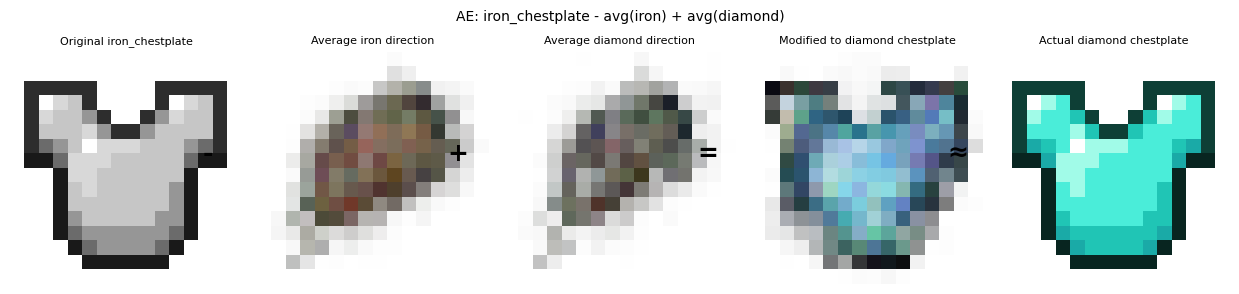


-- VAE Latent Space Arithmetic --
14 items found for keyword "iron"
11 items found for keyword "diamond"


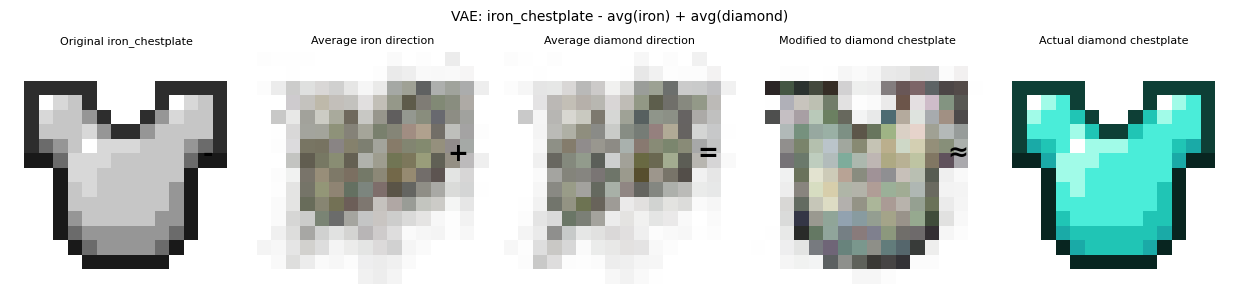

In [ ]:
def encode_items_by_keyword(model, dataset, keyword, is_vae=False):
    """
    Finds all textures whose filename contains the keyword
    and returns their latent vectors.
    E.g. keyword='iron' returns all iron_*.png items.
    """
    model.eval()
    vectors = []

    with torch.no_grad():
        for img, path in dataset:
            filename = os.path.basename(path).lower()
            if keyword.lower() in filename:
                inp = img.unsqueeze(0).to(DEVICE)
                if is_vae:
                    mu, _ = model.encoder(inp)   # Use mu as representation (no sampling)
                    vectors.append(mu.squeeze(0).cpu())
                else:
                    z = model.encoder(inp)
                    vectors.append(z.squeeze(0).cpu())

    if not vectors:
        print(f'No items found with keyword: "{keyword}"')
        return None

    print(f'{len(vectors)} items found for keyword "{keyword}"')
    return torch.stack(vectors)   # Shape: (n_items, LATENT_DIM)


def encode_single_item(model, dataset, filename, is_vae=False):
    """
    Encodes one specific texture based on filename.
    Returns the latent vector and the original image tensor.
    """
    model.eval()
    with torch.no_grad():
        for img, path in dataset:
            if filename.lower() in os.path.basename(path).lower():
                inp = img.unsqueeze(0).to(DEVICE)
                if is_vae:
                    mu, _ = model.encoder(inp)
                    return mu.squeeze(0).cpu(), img
                else:
                    z = model.encoder(inp)
                    return z.squeeze(0).cpu(), img
    print(f'Item not found: {filename}')
    return None, None


def decode_mean_material(model, z_vectors, is_vae=False):
    """
    Decodes the mean of a set of latent vectors into an image.
    Used to visualize the average iron / average diamond direction.
    """
    model.eval()
    mean_z = z_vectors.mean(dim=0)
    with torch.no_grad():
        z_in = mean_z.unsqueeze(0).to(DEVICE)
        img_out = model.decoder(z_in)
    return img_out.squeeze(0).permute(1, 2, 0).cpu().numpy(), mean_z


def latent_arithmetic(model, z_item, mean_from, mean_to, is_vae=False):
    """
    Performs latent space arithmetic:
    z_result = z_item - mean(z_material_from) + mean(z_material_to)

    Decodes the result and returns the generated image.
    """
    model.eval()

    # Vector operation in latent space
    z_result = z_item - mean_from + mean_to

    with torch.no_grad():
        z_in  = z_result.unsqueeze(0).to(DEVICE)
        img_out = model.decoder(z_in)

    return img_out.squeeze(0).permute(1, 2, 0).cpu().numpy()


def find_actual_item(dataset, keyword, exclude_keyword=None):
    """
    Finds the first image in the dataset whose filename contains keyword
    but does NOT contain exclude_keyword (to find e.g. the actual diamond
    chestplate, not an iron chestplate).
    Returns the image as a numpy array, or None if not found.
    """
    for img, path in dataset:
        fname = os.path.basename(path).lower()
        if keyword.lower() in fname:
            if exclude_keyword is None or exclude_keyword.lower() not in fname:
                return img.permute(1, 2, 0).numpy()
    return None


# -- Run experiment for both AE and VAE --------------------------------------
# Adjust filenames based on actual names in your dataset
ITEM_NAME     = 'iron_chestplate'   # Item to transform
MATERIAL_FROM = 'iron'              # Material of the original item
MATERIAL_TO   = 'diamond'           # Target material

for model, label, is_vae in [(ae_model, 'AE', False), (vae_model, 'VAE', True)]:
    print(f'\n-- {label} Latent Space Arithmetic --')

    z_item, original_img = encode_single_item(model, dataset, ITEM_NAME,     is_vae)
    z_from               = encode_items_by_keyword(model, dataset, MATERIAL_FROM, is_vae)
    z_to                 = encode_items_by_keyword(model, dataset, MATERIAL_TO,   is_vae)

    if z_item is None or z_from is None or z_to is None:
        print(f'Skipping {label} - items not found.')
        continue

    # Decode mean material directions for display
    mean_from_img, mean_from_z = decode_mean_material(model, z_from, is_vae)
    mean_to_img,   mean_to_z   = decode_mean_material(model, z_to,   is_vae)

    # Perform the arithmetic
    result_img = latent_arithmetic(model, z_item, mean_from_z, mean_to_z, is_vae)

    # Try to find the actual target item for comparison (e.g. diamond_chestplate)
    actual_target_img = find_actual_item(dataset,
                                         f'{MATERIAL_TO}_chestplate',
                                         exclude_keyword=MATERIAL_FROM)

    # Build a 5-panel figure matching the assignment preview
    n_panels = 5 if actual_target_img is not None else 4
    fig, axes = plt.subplots(1, n_panels, figsize=(n_panels * 2.5, 3))

    panels = [
        (original_img.permute(1, 2, 0).numpy(), f'Original {ITEM_NAME}'),
        (mean_from_img,                          f'Average {MATERIAL_FROM} direction'),
        (mean_to_img,                            f'Average {MATERIAL_TO} direction'),
        (result_img,                             f'Modified to {MATERIAL_TO} chestplate'),
    ]
    if actual_target_img is not None:
        panels.append((actual_target_img, f'Actual {MATERIAL_TO} chestplate'))

    for i, (img_np, title) in enumerate(panels):
        ax = axes[i]
        ax.imshow(np.clip(img_np, 0, 1))
        ax.set_title(title, fontsize=8)
        ax.axis('off')

    plt.suptitle(
        f'{label}: {ITEM_NAME} - avg({MATERIAL_FROM}) + avg({MATERIAL_TO})',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()


## 7. Latent space visualization (t-SNE)

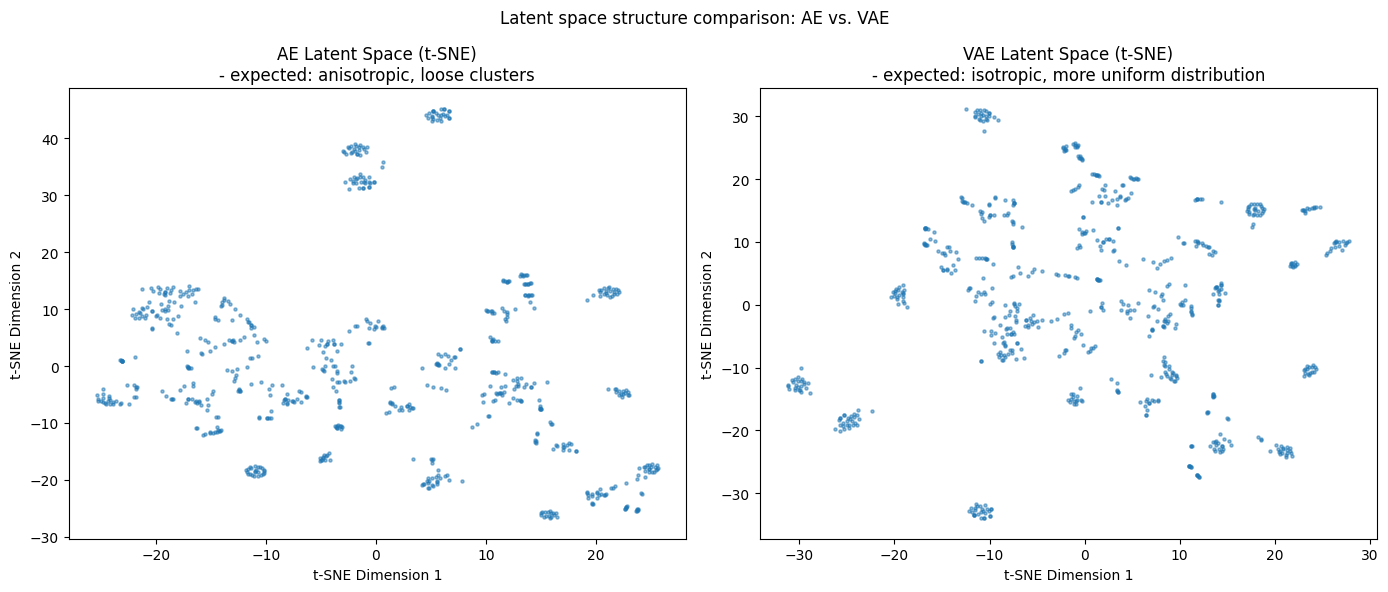

In [27]:
def get_all_latent_vectors(model, dataset, is_vae=False):
    """
    Encodes the full dataset to latent vectors.
    Used for t-SNE visualization of latent space structure.
    """
    model.eval()
    vectors = []
    with torch.no_grad():
        for img, _ in dataset:
            inp = img.unsqueeze(0).to(DEVICE)
            if is_vae:
                mu, _ = model.encoder(inp)
                vectors.append(mu.squeeze(0).cpu().numpy())
            else:
                z = model.encoder(inp)
                vectors.append(z.squeeze(0).cpu().numpy())
    return np.array(vectors)


# Get latent vectors for AE and VAE
ae_vectors  = get_all_latent_vectors(ae_model,  dataset, is_vae=False)
vae_vectors = get_all_latent_vectors(vae_model, dataset, is_vae=True)

# Reduce to 2D with t-SNE for visualization
ae_tsne  = TSNE(n_components=2, random_state=42).fit_transform(ae_vectors)
vae_tsne = TSNE(n_components=2, random_state=42).fit_transform(vae_vectors)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(ae_tsne[:,  0], ae_tsne[:,  1], s=5, alpha=0.5)
axes[0].set_title('AE Latent Space (t-SNE)\n- expected: anisotropic, loose clusters')
axes[1].scatter(vae_tsne[:, 0], vae_tsne[:, 1], s=5, alpha=0.5)
axes[1].set_title('VAE Latent Space (t-SNE)\n- expected: isotropic, more uniform distribution')
for ax in axes:
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
plt.suptitle('Latent space structure comparison: AE vs. VAE')
plt.tight_layout()
plt.show()